# Initialize

In [1]:
#Imports
import os
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
#Helper
def get_directories(directory):
    """
    Returns a list of directories in the specified folder path.

    Args:
        folder_path (str): The path of the folder to get the directories from.

    Returns:
        list: A list of directory names.
    """
    # Get a list of directories in the specified folder
    # Filter the list to include only directories (excluding the "figures" directory)
    directories = [name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name)) and name!="figures"]
    return directories

#Classes
class Animal:
    """
    This class represents an animal in an experiment.

    Attributes:
    root_dir (str): The root directory where the data is stored.
    sessions (dict): A dictionary to store session objects for this animal.
    cohort_year (int): The year of the cohort that the animal belongs to.
    dob (str): The date of birth of the animal.
    animal_id (str): The ID of the animal.
    pdays (list of int): The postnatal days when the sessions were conducted.
    session_dates (list of str): The dates when the sessions were conducted.
    session_names (list of str): The names of the sessions.
    sex (str): The sex of the animal.

    Methods:
    load_data(yaml_path): Loads metadata for the animal from a YAML file.
    get_session_data(session_id, print_loading=True): Loads data for a specific session.
    """
    root_dir = r"\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\rodrigo"

    def __init__(self, yaml_file_path, print_loading=True) -> None:
        self.sessions = {}
        self.cohort_year = None
        self.dob = None
        self.animal_id = None 
        self.pdays = None 
        self.session_dates = None 
        self.session_names = None 
        self.sex = None 
        self.load_data(yaml_file_path)
        self.animal_dir = os.path.join(Animal.root_dir, self.animal_id)
        if print_loading:
            print(f"Loaded animal: {self.animal_id}")

    def load_data(self, yaml_path):
        with open(yaml_path, "r") as yaml_file:
            animal_metadata_dict = yaml.safe_load(yaml_file)
        self.cohort_year = int(animal_metadata_dict["cohort_year"])
        self.dob = animal_metadata_dict["dob"]
        self.animal_id = animal_metadata_dict["name"]
        self.pdays = [int(pday) for pday in animal_metadata_dict["pdays"]]
        self.session_dates = animal_metadata_dict["session_dates"]
        self.session_names = animal_metadata_dict["session_names"]
        self.sex = animal_metadata_dict["sex"]
    
    def get_session_data(self, session_id, print_loading=True):
        yaml_file_index = self.session_names.index(session_id)
        session = Session(self.animal_id, session_id, age=self.pdays[yaml_file_index], 
                        session_date=self.session_dates[yaml_file_index], print_loading=print_loading)
        self.sessions[session_id] = session
        #return corr_mat, pval_mat, zscore_mat

class Session:
    """
    This class represents a session in an experiment.

    Attributes:
    corr_fname (str): The filename where the correlation data is stored.
    animal_id (str): The ID of the animal that this session belongs to.
    session_id (str): The ID of this session.
    session_date (str): The date when this session was conducted.
    session_dir (str): The directory where the data for this session is stored.
    age (int): The age of the animal at the time of this session.
    corr_mat, pval_mat, zscore_mat: Numpy arrays to store correlation data.

    Methods:
    get_correlation_data(): Loads correlation data for this session from a file.
    """
    corr_fname = "allcell_clean_corr_pval_zscore.npy"

    def __init__(self, animal_id, session_id, age, session_date, print_loading=True):
        if print_loading:
            print(f"Loading session: {animal_id} {session_id}")
        self.animal_id = animal_id
        self.session_id = session_id
        self.session_date = session_date
        self.age = age
        self.session_dir = os.path.join(Animal.root_dir, animal_id, session_id)
        self.corr_mat, self.pval_mat, self.zscore_mat = None, None, None
        self.get_correlation_data()

    def get_correlation_data(self):
        self.corr_mat, self.pval_mat, self.zscore_mat = np.load(os.path.join(self.session_dir, Session.corr_fname))
        return self.corr_mat, self.pval_mat, self.zscore_mat

In [2]:
def load_all(root_dir, wanted_animal_ids=["all"], wanted_session_ids=["all"], print_loading=True):
    """
    Loads animal data from the specified root directory for the given animal IDs.

    Parameters:
    - root_dir (string): The root directory path where the animal data is stored.
    - animal_ids (list, optional): A list of animal IDs to load. Default is ["all"].
    - generate (bool, optional): If True, generates new session data. Default is False.
    - regenerate (bool, optional): If True, regenerates existing session data. Default is False.
    - units (string, optional): Specifies the units. Default is "single".
    - delete (bool, optional): If True, deletes session data. Default is False.

    Returns:
    - animals_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.
    """
    present_animal_ids = get_directories(root_dir)
    animals_dict = {}

    # Search for animal_ids
    for animal_id in present_animal_ids:
        if animal_id in wanted_animal_ids or "all" in wanted_animal_ids:
            sessions_path = os.path.join(root_dir, animal_id)
            present_sessions = get_directories(sessions_path)
            yaml_file_name = os.path.join(root_dir, animal_id, f"{animal_id}.yaml")
            animal = Animal(yaml_file_name, print_loading=print_loading)
            Animal.root_dir = root_dir
            # Search for 2P Sessions
            for session in present_sessions:
                if session in wanted_session_ids or "all" in wanted_session_ids:
                    animal.get_session_data(session, print_loading=print_loading)
            animals_dict[animal_id] = animal
    return animals_dict

# Work Examples

In [3]:
# Root directory should be changed in Animal class too, if necessary
#different_root_dir = r"\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\rodrigo"
#Animal.root_dir = different_root_dir
#root_dir = r"\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\rodrigo"
root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments/rodrigo" 
mice21 = ["DON-002865", "DON-003165", "DON-003343", "DON-006084", "DON-006085", "DON-006087"]
mice22 = ["DON-008497", "DON-008498", "DON-008499", "DON-009191", "DON-009192", "DON-010473", "DON-010477"]
mice23 = ["DON-014837", "DON-014838", "DON-014840", "DON-014847", "DON-014849", "DON-015078", "DON-015079"]

In [4]:
wanted_animal_ids = ["DON-002865"]
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=["all"], print_loading=True)

Loaded animal: DON-002865
Loading session: DON-002865 20210217
Loading session: DON-002865 20210213
Loading session: DON-002865 20210218
Loading session: DON-002865 20210211
Loading session: DON-002865 20210216
Loading session: DON-002865 20210214
Loading session: DON-002865 20210210
Loading session: DON-002865 20210219
Loading session: DON-002865 20210215
Loading session: DON-002865 20210212


DON-002865 20210217


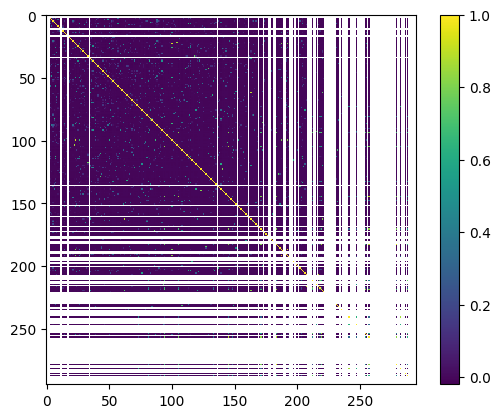

DON-002865 20210213


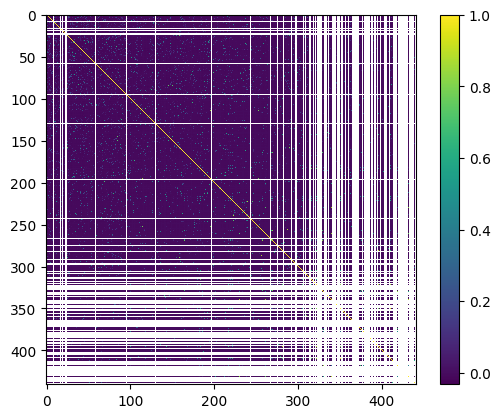

DON-002865 20210218


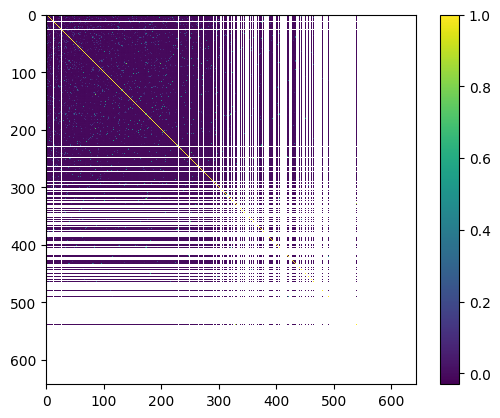

DON-002865 20210211


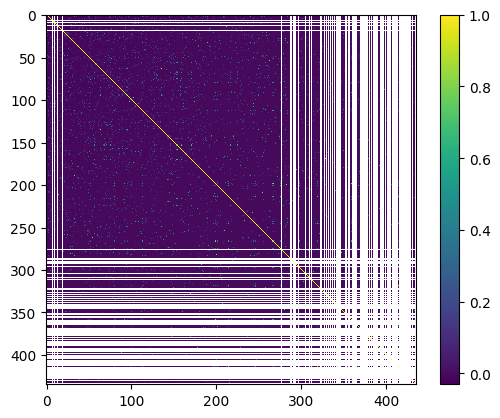

DON-002865 20210216


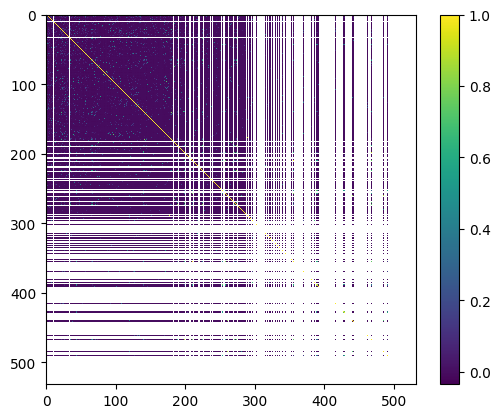

DON-002865 20210214


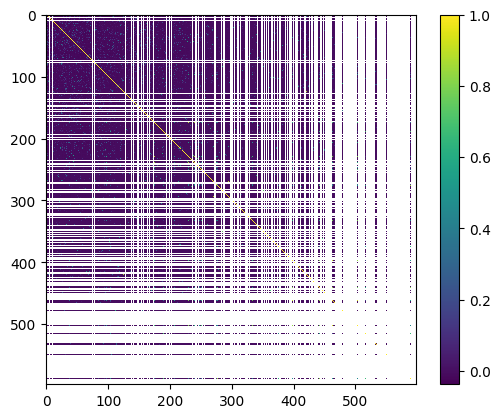

DON-002865 20210210


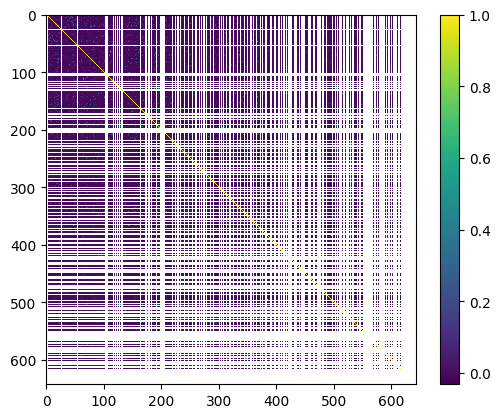

DON-002865 20210219


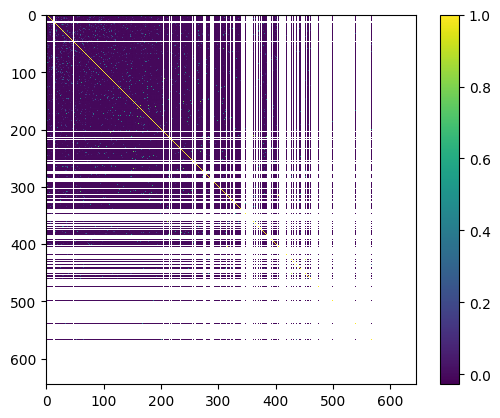

DON-002865 20210215


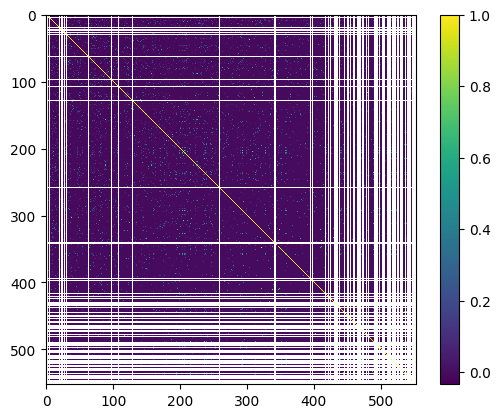

DON-002865 20210212


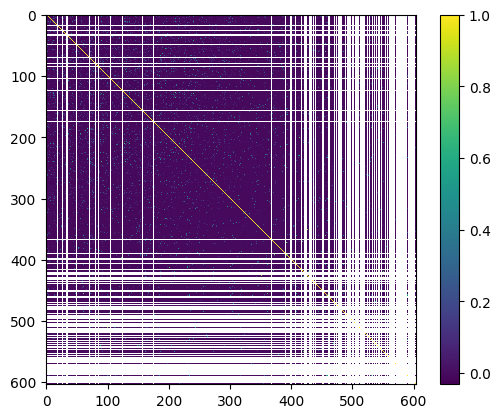

In [5]:
# corr_mat, pval_mat, zscore_mat are matrices with size (n_cells, n_cells)
for animal_id, animal in animals.items():
    if animal.cohort_year == 2021:
        for session_id, session in animal.sessions.items():
            print(f"{animal_id} {session_id}")

            plt.imshow(session.corr_mat, interpolation="none")
            plt.colorbar()
            plt.show()

            #plt.figure(figsize=(3,3))
            #sns.histplot(session.corr_mat.flatten())
#
            #plt.figure(figsize=(3,3))
            #sns.histplot(session.pval_mat.flatten())
#
            #plt.figure(figsize=(3,3))
            #sns.histplot(session.zscore_mat.flatten())

In [8]:
wanted_animal_ids = mice21+mice22
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=["all"], print_loading=False)

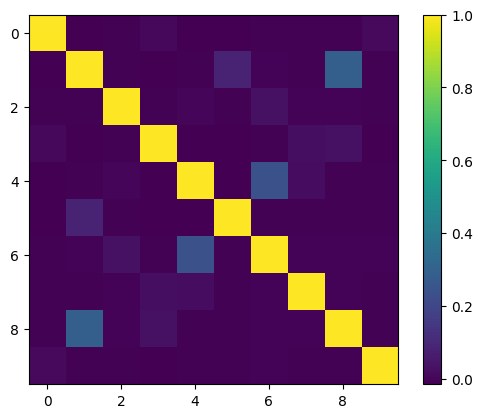

In [9]:
session = animals["DON-006084"].sessions["20210519"]
plt.imshow(session.corr_mat, interpolation="none")
plt.colorbar()
plt.show()